# Jackiw-Rebbi solitons in a honeycomb ribbon
Near the Dirac points, honeycomb electrons obey an effective 2D Dirac equation, and a uniform sublattice-imbalance mass $M$ opens a gap there (see the bands notebook). The Jackiw-Rebbi mechanism says that if the mass instead changes sign along a line — a domain wall $M(y)=M_0\,\mathrm{sign}(y)$ — a single, topologically protected zero-energy mode gets bound to that line, dispersing freely along it. We build exactly this domain wall across the width of a honeycomb ribbon and see the soliton appear as an in-gap band crossing zero energy.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Create a wide zigzag ribbon
Periodic along $x$, finite (40 atomic rows) along $y$ — wide enough that the domain-wall state at $y=0$ doesn't overlap the physical edges of the ribbon.
$$ H = \sum_{\langle ij \rangle} c^\dagger_i c_j $$

In [2]:
g = geometry.honeycomb_zigzag_ribbon(20) # create the geometry
h = g.get_hamiltonian() # create hamiltonian of the system
hs = h.copy() # create a copy of the Hamiltonian, which will have the soliton solution

### Add the sublattice-imbalance mass: uniform vs. a domain wall
`h` gets the same mass everywhere (gapped, no soliton). `hs` gets a mass that flips sign at $y=0$, `M(y)=M_0\,\mathrm{sign}(y)$ — the domain wall that binds the Jackiw-Rebbi mode.

In [3]:
h.add_sublattice_imbalance(0.5) # same sublattice imbalance everywhere
hs.add_sublattice_imbalance(lambda r: np.sign(r[1])*0.5) # domain wall in the sublattice imbalance

### Diagonalize both Bloch Hamiltonians
$$ H \left | \Psi_k \right \rangle = \epsilon_k \left | \Psi_k \right \rangle $$

In [4]:
(k,e) = h.get_bands() # get the bandstructure
(ks,es) = hs.get_bands() # get the bandstructure

### Plot the band structure: a zero mode appears only for the domain wall
The uniform mass fully gaps the ribbon. The domain-wall mass leaves a single band crossing zero energy — the Jackiw-Rebbi soliton, dispersing along the ribbon direction.

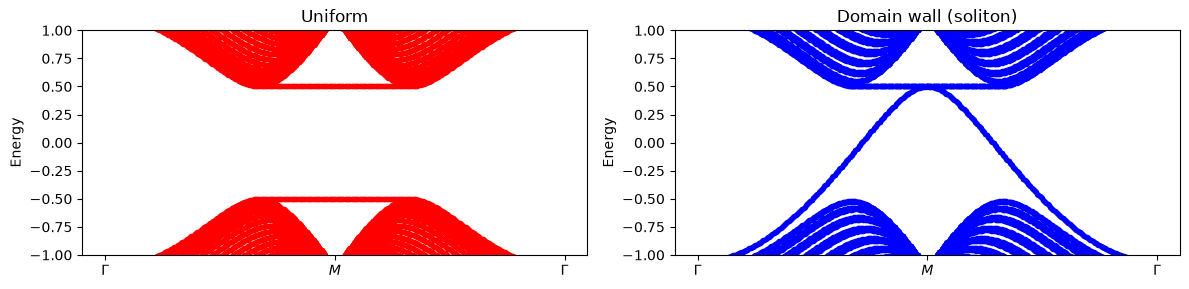

In [5]:
fig = plt.figure(figsize=(12, 3)) # set the right ratio
plt.subplot(121)
plt.title("Uniform")
plt.scatter(k/max(k),e,c="red",s=8) # do a scatter plot
plt.ylabel("Energy") # set the y label
plt.xticks([0.,0.5,1.],["$\Gamma$","$M$","$\Gamma$"])
plt.ylim([-1.,1.])

plt.subplot(122)
plt.title("Domain wall (soliton)")
plt.scatter(ks/max(ks),es,c="blue",s=8) # do a scatter plot
plt.ylabel("Energy") # set the y label
plt.xticks([0.,0.5,1.],["$\Gamma$","$M$","$\Gamma$"])
plt.ylim([-1.,1.])

plt.tight_layout()
plt.show()

### Real-space confirmation: the LDOS at $E=0$ is bound to the domain wall
`h.get_ldos` at zero energy, averaged over the ribbon's periodic direction, should show weight concentrated at $y=0$ and decaying away from it on both sides — the soliton's wavefunction.

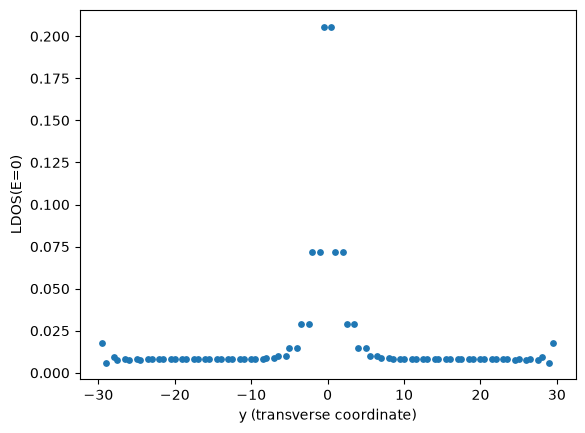

In [6]:
(x,y,d) = hs.get_ldos(e=0.0,delta=0.02,nk=100,nrep=1,write=False)
plt.scatter(y,d,s=15)
plt.xlabel("y (transverse coordinate)") ; plt.ylabel("LDOS(E=0)")
plt.show()